# Modelagem Preditiva - Risco de Defasagem

## Objetivo
Construir um modelo preditivo de risco de defasagem com metodologia unica e explicitamente alinhada aos criterios de avaliacao da banca:
1. Feature engineering
2. Separacao treino e teste
3. Modelagem preditiva
4. Avaliacao dos resultados

## Metodologia aplicada
A metodologia deste notebook e temporal:
- Features no ano t
- Alvo de risco no ano t+1

Essa estrutura busca reduzir leakage temporal e aumentar a aderencia ao uso real do modelo.

## Definicao operacional do alvo
1. Construimos `inde_combined` no ano t usando prioridade temporal (`inde_2024`, `inde_2023`, `inde_2022`).
2. Construimos `inde_next_year` por aluno com `shift(-1)` em ordem cronologica.
3. Definimos risco no ano t+1 como estar no quartil inferior (Q1) de `inde_next_year`, com limiar calculado apenas no treino.

## Separacao de treino e teste
Aplicamos separacao temporal para evitar contaminacao de informacao futura:
- Treino: observacoes base em 2022 (prevendo 2023)
- Teste: observacoes base em 2023 (prevendo 2024)

Essa estrategia simula o fluxo real de previsao: treinar no passado para prever o futuro.

## Estrategia de modelagem
Mantemos duas trilhas para lidar com disponibilidade de IPP:
- Trilha 1 (sem IPP): maior cobertura amostral
- Trilha 2 (com IPP): menor cobertura, maior riqueza psicopedagogica

## Criterio de selecao
1. Prioridade: maior `recall` (reduzir falsos negativos de alunos em risco).
2. Desempate: maior `roc_auc`.

## O que e apresentado na avaliacao
- Tabela de metricas por trilha/modelo
- Matriz de confusao
- Curva ROC
- Curva Precision-Recall
- Curva de calibracao
- Analise de threshold (precision/recall/f1 por limiar)

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    brier_score_loss
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone
from sklearn.calibration import calibration_curve

import joblib

project_root = Path.cwd().parent
data_path = project_root / "data" / "dados_unificados.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Arquivo oficial não encontrado: {data_path}")
models_dir = project_root / "models"
outputs_dir = project_root / "outputs"
models_dir.mkdir(exist_ok=True)
outputs_dir.mkdir(exist_ok=True)

print(f"Data: {data_path}")
print(f"Models: {models_dir}")
print(f"Outputs: {outputs_dir}")

Data: c:\Users\nykol\Python\Pós Tech\Módulo 5\fiap-datathon-fase5\data\dados_unificados.csv
Models: c:\Users\nykol\Python\Pós Tech\Módulo 5\fiap-datathon-fase5\models
Outputs: c:\Users\nykol\Python\Pós Tech\Módulo 5\fiap-datathon-fase5\outputs


In [2]:
df = pd.read_csv(data_path)

# 1) Feature engineering do INDE no ano t
inde_priority = [c for c in ["inde_2024", "inde_2023", "inde_2022"] if c in df.columns]
if not inde_priority:
    raise ValueError("Nenhuma coluna INDE encontrada (inde_2022/inde_2023/inde_2024).")

for c in inde_priority:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["inde_combined"] = df[inde_priority].bfill(axis=1).iloc[:, 0]
valid_mask = df[inde_priority].notna().any(axis=1)
df["inde_reference_year"] = df[inde_priority].notna().idxmax(axis=1).where(valid_mask, pd.NA)

# 2) Construir alvo temporal: risco no ano t+1
if "year" not in df.columns or "student_id" not in df.columns:
    raise ValueError("Colunas obrigatorias ausentes: 'year' e/ou 'student_id'.")

df["year_num"] = pd.to_numeric(df["year"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce")
df = df.sort_values(["student_id", "year_num"]).copy()

df["inde_next_year"] = df.groupby("student_id")["inde_combined"].shift(-1)
df["next_year_num"] = df.groupby("student_id")["year_num"].shift(-1)
consecutive_mask = df["next_year_num"] == (df["year_num"] + 1)
df.loc[~consecutive_mask, "inde_next_year"] = np.nan

model_df = df.dropna(subset=["inde_next_year", "year_num"]).copy()
model_df["base_year"] = model_df["year_num"].astype(int)
model_df["prediction_year"] = model_df["base_year"] + 1

train_df = model_df[model_df["base_year"] == 2022].copy()
test_df = model_df[model_df["base_year"] == 2023].copy()

if train_df.empty or test_df.empty:
    raise ValueError("Split temporal invalido: treino e/ou teste vazio.")

q1_next_train = train_df["inde_next_year"].quantile(0.25)
train_df["target_risco_next"] = (train_df["inde_next_year"] <= q1_next_train).astype(int)
test_df["target_risco_next"] = (test_df["inde_next_year"] <= q1_next_train).astype(int)

print("Shape original:", df.shape)
print("Fonte:", data_path.name)
print("Anos base disponiveis para modelagem:", sorted(model_df["base_year"].unique().tolist()))
print("INDE prioridade:", inde_priority)
print("Q1 treino (inde_next_year):", round(float(q1_next_train), 4))
print("Treino (base 2022):", train_df.shape[0], "linhas")
print("Teste (base 2023):", test_df.shape[0], "linhas")
print("Taxa de risco no treino (%):", round(float(train_df["target_risco_next"].mean() * 100), 2))
print("Taxa de risco no teste (%):", round(float(test_df["target_risco_next"].mean() * 100), 2))

Shape original: (3030, 35)
Fonte: dados_unificados.csv
Anos base disponiveis para modelagem: [2022, 2023]
INDE prioridade: ['inde_2024', 'inde_2023', 'inde_2022']
Q1 treino (inde_next_year): 6.6285
Treino (base 2022): 600 linhas
Teste (base 2023): 722 linhas
Taxa de risco no treino (%): 25.0
Taxa de risco no teste (%): 21.47


In [3]:
BASE_FEATURES = [
    "phase", "age", "ian", "ida", "ieg", "iaa", "ips", "ipv", "inde_combined",
    "math", "portuguese", "english", "deficiency", "gender",
    "school_institution", "achieved_turning_point", "indicated_for_intervention"
]


def get_existing_features(train_frame, test_frame, include_ipp=False):
    features = BASE_FEATURES.copy()
    if include_ipp:
        features.append("ipp")

    usable = []
    for feature in features:
        if feature not in train_frame.columns or feature not in test_frame.columns:
            continue

        train_missing = train_frame[feature].isna().mean()
        test_missing = test_frame[feature].isna().mean()
        train_unique = train_frame[feature].nunique(dropna=True)

        if train_missing >= 0.95 or test_missing >= 0.95 or train_unique <= 1:
            continue
        usable.append(feature)

    return usable


def evaluate_binary(y_true, y_pred, y_prob):
    metrics = {
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob))
    }
    cm = confusion_matrix(y_true, y_pred)
    metrics["tn"], metrics["fp"], metrics["fn"], metrics["tp"] = [int(x) for x in cm.ravel()]
    return metrics


def build_preprocessor(X):
    num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    pre = ColumnTransformer(transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ])
    return pre


def run_track_temporal(train_frame, test_frame, track_name, include_ipp=False):
    feats = get_existing_features(train_frame, test_frame, include_ipp=include_ipp)
    if len(feats) == 0:
        raise ValueError(f"{track_name}: nenhuma feature utilizavel apos filtros de qualidade.")

    X_train = train_frame[feats].copy()
    y_train = train_frame["target_risco_next"].copy()
    X_test = test_frame[feats].copy()
    y_test = test_frame["target_risco_next"].copy()

    pre = build_preprocessor(X_train)

    models = {
        "logistic": LogisticRegression(max_iter=2000, class_weight="balanced"),
        "random_forest": RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            random_state=42,
            class_weight="balanced_subsample",
            n_jobs=-1
        ),
        "gradient_boosting": GradientBoostingClassifier(random_state=42)
    }

    rows = []
    fitted = {}
    scored_outputs = {}

    for model_name, model in models.items():
        pipe = Pipeline(steps=[
            ("pre", clone(pre)),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)
        y_prob = pipe.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        metrics = evaluate_binary(y_test, y_pred, y_prob)
        row = {
            "track": track_name,
            "model": model_name,
            "n_train": int(len(train_frame)),
            "n_test": int(len(test_frame)),
            "n_features": int(len(feats)),
            "train_base_year": int(train_frame["base_year"].min()),
            "test_base_year": int(test_frame["base_year"].min()),
            **metrics
        }
        rows.append(row)
        fitted[model_name] = pipe
        scored_outputs[model_name] = {
            "y_true": y_test.to_numpy(),
            "y_pred": y_pred,
            "y_prob": y_prob
        }

    result = pd.DataFrame(rows).sort_values(["recall", "roc_auc"], ascending=False).reset_index(drop=True)
    best_name = result.iloc[0]["model"]

    return {
        "track": track_name,
        "features": feats,
        "metrics_table": result,
        "best_model_name": best_name,
        "best_model": fitted[best_name],
        "best_scored": scored_outputs[best_name],
        "all_scored": scored_outputs
    }

## Leitura dos resultados e criterio de decisao

A avaliacao dos modelos segue um criterio unico e explicito:

1. **Priorizar `recall`**
   - Motivo: reduzir falsos negativos (alunos em risco nao detectados).

2. **Desempatar por `roc_auc`**
   - Motivo: medir capacidade global de separacao entre classes em diferentes limiares.

3. **Registrar trilha e modelo vencedores em metadata**
   - Motivo: garantir rastreabilidade e reproducibilidade para auditoria metodologica.

Observacao: `precision`, `f1`, `pr_auc`, matriz de confusao e curvas de avaliacao sao reportadas para discussao transparente dos trade-offs operacionais.

In [4]:
# Trilha 1: maior cobertura amostral (sem IPP)
track1 = run_track_temporal(
    train_frame=train_df.copy(),
    test_frame=test_df.copy(),
    track_name="trilha_temporal_sem_ipp",
    include_ipp=False
)
track1["metrics_table"]

,track,model,n_train,n_test,n_features,train_base_year,test_base_year,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,trilha_temporal_sem_ipp,logistic,600,722,14,2022,2023,0.543046,0.529032,0.535948,0.808136,0.554086,498,69,73,82
1,trilha_temporal_sem_ipp,gradient_boosting,600,722,14,2022,2023,0.658537,0.348387,0.455696,0.804597,0.564016,539,28,101,54
2,trilha_temporal_sem_ipp,random_forest,600,722,14,2022,2023,0.647059,0.283871,0.394619,0.811458,0.547256,543,24,111,44


In [5]:
# Trilha 2: incluir IPP exige linhas com IPP observado em treino e teste
if "ipp" in train_df.columns and "ipp" in test_df.columns:
    train_ipp = train_df[train_df["ipp"].notna()].copy()
    test_ipp = test_df[test_df["ipp"].notna()].copy()

    if train_ipp.empty or test_ipp.empty or train_ipp["target_risco_next"].nunique() < 2:
        track2 = None
        print("Trilha temporal com IPP sem dados suficientes apos filtro de disponibilidade.")
    else:
        track2 = run_track_temporal(
            train_frame=train_ipp,
            test_frame=test_ipp,
            track_name="trilha_temporal_com_ipp",
            include_ipp=True
        )
        display(track2["metrics_table"])
else:
    track2 = None
    print("Coluna IPP nao encontrada para trilha com IPP.")

Trilha temporal com IPP sem dados suficientes apos filtro de disponibilidade.


In [6]:
all_tables = [track1["metrics_table"]]
candidates = [(track1["track"], track1)]

if track2 is not None:
    all_tables.append(track2["metrics_table"])
    candidates.append((track2["track"], track2))

leaderboard = pd.concat(all_tables, ignore_index=True)
leaderboard = leaderboard.sort_values(["recall", "roc_auc"], ascending=False).reset_index(drop=True)
display(leaderboard)

winner_track_name = leaderboard.iloc[0]["track"]
winner_model_name = leaderboard.iloc[0]["model"]
winner_obj = next(obj for name, obj in candidates if name == winner_track_name)
winner_model = winner_obj["best_model"]
winner_scores = winner_obj["best_scored"]

model_path = models_dir / "model_risco.joblib"
joblib.dump(winner_model, model_path)

leaderboard_path = outputs_dir / "modelagem_leaderboard.csv"
leaderboard.to_csv(leaderboard_path, index=False, encoding="utf-8")

metadata = {
    "target_definition": "target_risco_next = 1 quando inde_next_year <= Q1 do treino",
    "q1_train_inde_next_year": float(q1_next_train),
    "split_strategy": "temporal (treino: base 2022 -> alvo 2023; teste: base 2023 -> alvo 2024)",
    "winner_track": winner_track_name,
    "winner_model": winner_model_name,
    "winner_metrics": leaderboard.iloc[0].to_dict(),
    "track1": {
        "features": track1["features"]
    },
    "track2": None if track2 is None else {
        "features": track2["features"]
    }
}

metadata_path = outputs_dir / "model_risco_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as fp:
    json.dump(metadata, fp, ensure_ascii=False, indent=2)

# Persistir previsoes do modelo vencedor para auditoria
predictions_out = pd.DataFrame({
    "y_true": winner_scores["y_true"],
    "y_pred": winner_scores["y_pred"],
    "y_prob": winner_scores["y_prob"]
})
predictions_path = outputs_dir / "predicoes_modelo_vencedor.csv"
predictions_out.to_csv(predictions_path, index=False, encoding="utf-8")

print(f"Modelo salvo em: {model_path}")
print(f"Leaderboard salvo em: {leaderboard_path}")
print(f"Metadata salvo em: {metadata_path}")
print(f"Predicoes do vencedor salvas em: {predictions_path}")
print(f"Vencedor: {winner_track_name} / {winner_model_name}")

,track,model,n_train,n_test,n_features,train_base_year,test_base_year,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,trilha_temporal_sem_ipp,logistic,600,722,14,2022,2023,0.543046,0.529032,0.535948,0.808136,0.554086,498,69,73,82
1,trilha_temporal_sem_ipp,gradient_boosting,600,722,14,2022,2023,0.658537,0.348387,0.455696,0.804597,0.564016,539,28,101,54
2,trilha_temporal_sem_ipp,random_forest,600,722,14,2022,2023,0.647059,0.283871,0.394619,0.811458,0.547256,543,24,111,44


Modelo salvo em: c:\Users\nykol\Python\Pós Tech\Módulo 5\fiap-datathon-fase5\models\model_risco.joblib
Leaderboard salvo em: c:\Users\nykol\Python\Pós Tech\Módulo 5\fiap-datathon-fase5\outputs\modelagem_leaderboard.csv
Metadata salvo em: c:\Users\nykol\Python\Pós Tech\Módulo 5\fiap-datathon-fase5\outputs\model_risco_metadata.json
Predicoes do vencedor salvas em: c:\Users\nykol\Python\Pós Tech\Módulo 5\fiap-datathon-fase5\outputs\predicoes_modelo_vencedor.csv
Vencedor: trilha_temporal_sem_ipp / logistic


## Plots de avaliacao (motivo de cada grafico)

1. Matriz de confusao: evidencia tipos de erro (FN/FP) no limiar de decisao adotado.
2. Curva ROC: mostra separacao global entre classes em todos os limiares.
3. Curva Precision-Recall: mais informativa quando a classe positiva e minoritaria.
4. Curva de calibracao: verifica se probabilidades previstas sao confiaveis.
5. Curva de threshold: ajuda a escolher limiar operacional conforme custo de erro.

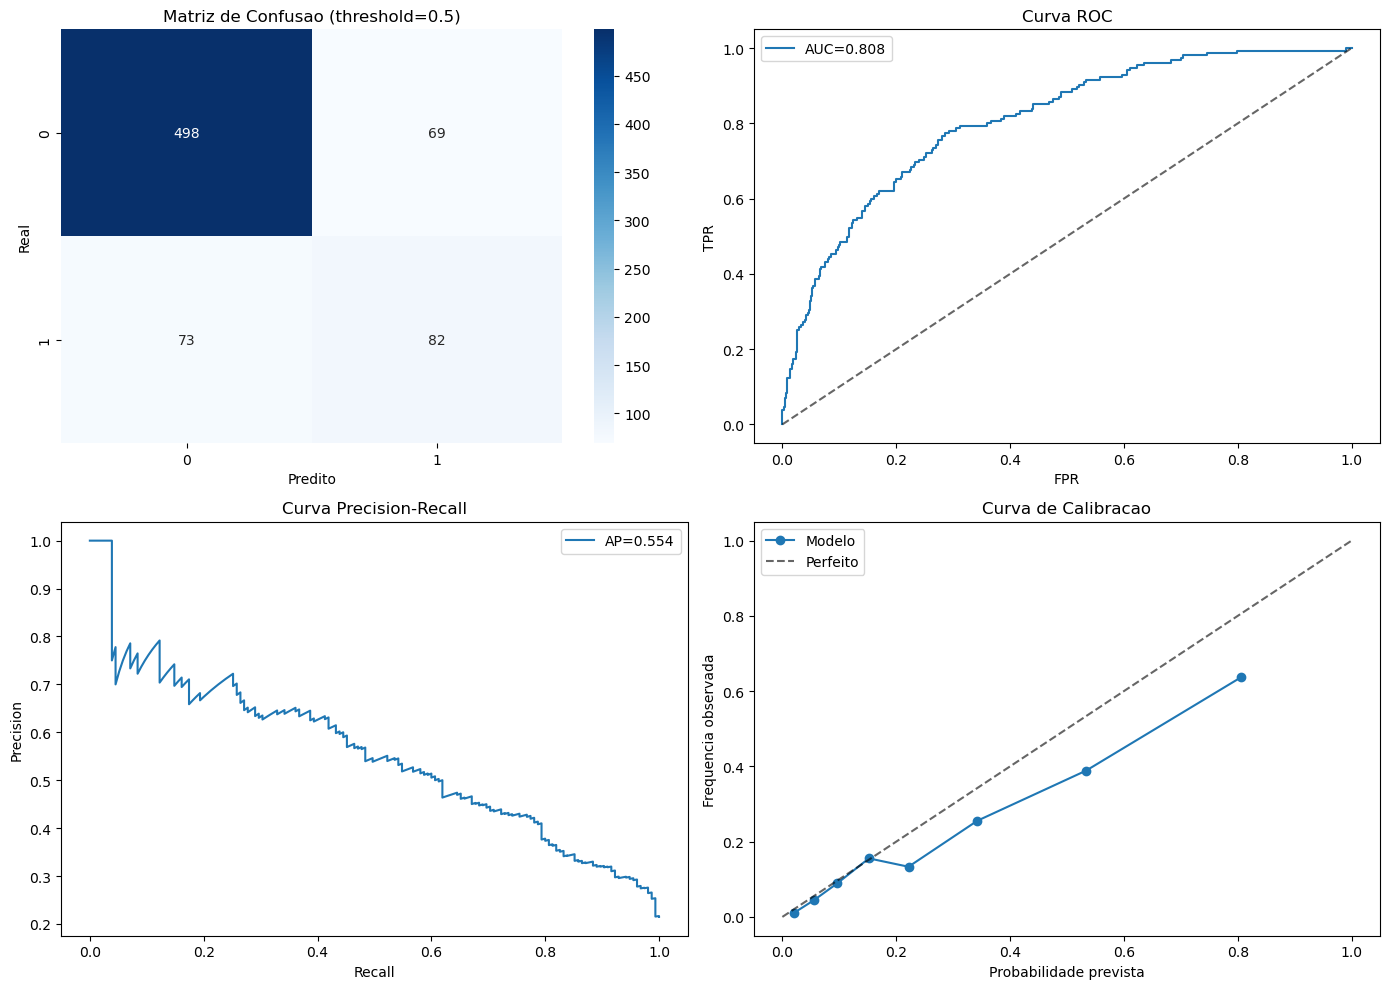

Brier score: 0.1387


,threshold,precision,recall,f1
0,0.10,0.296748,0.941935,0.451314
1,0.15,0.330049,0.864516,0.477718
2,0.20,0.366569,0.806452,0.504032
3,0.25,0.421603,0.780645,0.547511
4,0.30,0.435798,0.722581,0.543689
5,0.35,0.469484,0.645161,0.543478
6,0.40,0.487310,0.619355,0.545455
7,0.45,0.523256,0.580645,0.550459
8,0.50,0.543046,0.529032,0.535948
9,0.55,0.569231,0.477419,0.519298


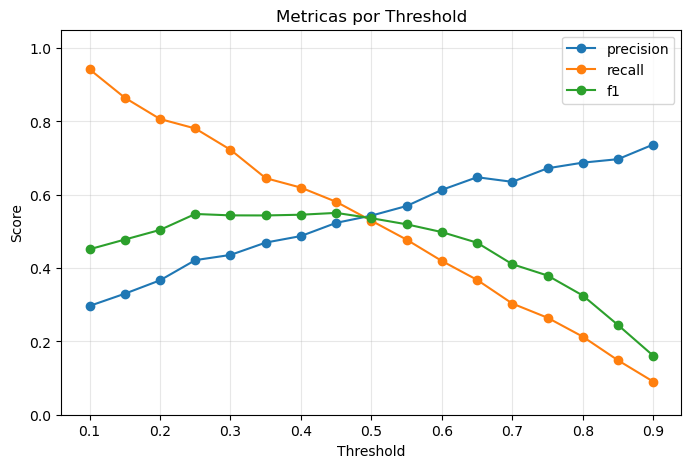

In [8]:
# Dados do modelo vencedor
y_true = winner_scores["y_true"]
y_pred = winner_scores["y_pred"]
y_prob = winner_scores["y_prob"]

# 1) Matriz de confusao
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, 0])
axes[0, 0].set_title("Matriz de Confusao (threshold=0.5)")
axes[0, 0].set_xlabel("Predito")
axes[0, 0].set_ylabel("Real")

# 2) Curva ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = roc_auc_score(y_true, y_prob)
axes[0, 1].plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
axes[0, 1].plot([0, 1], [0, 1], "k--", alpha=0.6)
axes[0, 1].set_title("Curva ROC")
axes[0, 1].set_xlabel("FPR")
axes[0, 1].set_ylabel("TPR")
axes[0, 1].legend()

# 3) Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)
axes[1, 0].plot(rec, prec, label=f"AP={pr_auc:.3f}")
axes[1, 0].set_title("Curva Precision-Recall")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend()

# 4) Curva de calibracao
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=8, strategy="quantile")
axes[1, 1].plot(prob_pred, prob_true, marker="o", label="Modelo")
axes[1, 1].plot([0, 1], [0, 1], "k--", alpha=0.6, label="Perfeito")
axes[1, 1].set_title("Curva de Calibracao")
axes[1, 1].set_xlabel("Probabilidade prevista")
axes[1, 1].set_ylabel("Frequencia observada")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("Brier score:", round(float(brier_score_loss(y_true, y_prob)), 4))

# 5) Sensibilidade ao threshold
threshold_grid = np.linspace(0.1, 0.9, 17)
threshold_rows = []
for thr in threshold_grid:
    pred_thr = (y_prob >= thr).astype(int)
    threshold_rows.append({
        "threshold": round(float(thr), 2),
        "precision": float(precision_score(y_true, pred_thr, zero_division=0)),
        "recall": float(recall_score(y_true, pred_thr, zero_division=0)),
        "f1": float(f1_score(y_true, pred_thr, zero_division=0))
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="f1")
plt.title("Metricas por Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Tabela de trade-off operacional (linguagem de negocio)

Esta secao transforma metricas tecnicas em opcoes de operacao para a equipe pedagogica.

Como ler:
- ponto_de_corte_alerta: regra usada para transformar probabilidade em alerta
- cobertura_risco_detectado: de cada 100 alunos que realmente entrariam em risco, quantos foram sinalizados
- taxa_de_acerto_dos_alertas: de cada 100 alertas emitidos, quantos eram risco real
- falsos_alertas: alunos sinalizados que nao entrariam em risco
- riscos_nao_detectados: alunos em risco que ficaram sem alerta

Regra pratica:
- reduzir o ponto de corte aumenta cobertura (menos alunos em risco ficam de fora),
  mas aumenta falsos alertas e demanda mais capacidade da equipe.

In [9]:
# Tabela de trade-off por ponto de corte
threshold_grid = np.round(np.arange(0.20, 0.85, 0.05), 2)

rows = []
for thr in threshold_grid:
    pred_thr = (y_prob >= thr).astype(int)
    cm_thr = confusion_matrix(y_true, pred_thr)
    tn, fp, fn, tp = cm_thr.ravel()

    coverage = recall_score(y_true, pred_thr, zero_division=0)  # cobertura de risco
    alert_precision = precision_score(y_true, pred_thr, zero_division=0)  # acerto dos alertas
    f1_thr = f1_score(y_true, pred_thr, zero_division=0)

    rows.append({
        "ponto_de_corte_alerta": float(thr),
        "alertas_emitidos": int(pred_thr.sum()),
        "cobertura_risco_detectado": float(coverage),
        "taxa_de_acerto_dos_alertas": float(alert_precision),
        "f1": float(f1_thr),
        "falsos_alertas": int(fp),
        "riscos_nao_detectados": int(fn),
        "verdadeiros_alertas": int(tp),
        "verdadeiros_nao_alertas": int(tn),
    })

tradeoff_df = pd.DataFrame(rows)
display(tradeoff_df)

# Sugestao automatica para capacidade operacional (top-N alertas)
capacity_targets = [80, 120, 160]
capacity_rows = []

for cap in capacity_targets:
    threshold_candidates = tradeoff_df[tradeoff_df["alertas_emitidos"] <= cap]
    if threshold_candidates.empty:
        chosen = tradeoff_df.iloc[0]
    else:
        chosen = threshold_candidates.sort_values(
            ["cobertura_risco_detectado", "taxa_de_acerto_dos_alertas"],
            ascending=[False, False]
        ).iloc[0]

    capacity_rows.append({
        "capacidade_max_alertas": int(cap),
        "ponto_de_corte_sugerido": float(chosen["ponto_de_corte_alerta"]),
        "alertas_emitidos": int(chosen["alertas_emitidos"]),
        "cobertura_risco_detectado": float(chosen["cobertura_risco_detectado"]),
        "taxa_de_acerto_dos_alertas": float(chosen["taxa_de_acerto_dos_alertas"]),
        "falsos_alertas": int(chosen["falsos_alertas"]),
        "riscos_nao_detectados": int(chosen["riscos_nao_detectados"]),
    })

capacity_df = pd.DataFrame(capacity_rows)
display(capacity_df)

tradeoff_path = outputs_dir / "modelagem_tradeoff_thresholds.csv"
capacity_path = outputs_dir / "modelagem_tradeoff_capacidade.csv"

tradeoff_df.to_csv(tradeoff_path, index=False, encoding="utf-8")
capacity_df.to_csv(capacity_path, index=False, encoding="utf-8")

print(f"Tabela de trade-off salva em: {tradeoff_path}")
print(f"Tabela por capacidade salva em: {capacity_path}")

,ponto_de_corte_alerta,alertas_emitidos,cobertura_risco_detectado,taxa_de_acerto_dos_alertas,f1,falsos_alertas,riscos_nao_detectados,verdadeiros_alertas,verdadeiros_nao_alertas
0,0.20,341,0.806452,0.366569,0.504032,216,30,125,351
1,0.25,287,0.780645,0.421603,0.547511,166,34,121,401
2,0.30,257,0.722581,0.435798,0.543689,145,43,112,422
3,0.35,213,0.645161,0.469484,0.543478,113,55,100,454
4,0.40,197,0.619355,0.487310,0.545455,101,59,96,466
5,0.45,172,0.580645,0.523256,0.550459,82,65,90,485
6,0.50,151,0.529032,0.543046,0.535948,69,73,82,498
7,0.55,130,0.477419,0.569231,0.519298,56,81,74,511
8,0.60,106,0.419355,0.613208,0.498084,41,90,65,526
9,0.65,88,0.367742,0.647727,0.469136,31,98,57,536


,capacidade_max_alertas,ponto_de_corte_sugerido,alertas_emitidos,cobertura_risco_detectado,taxa_de_acerto_dos_alertas,falsos_alertas,riscos_nao_detectados
0,80,0.7,74,0.303226,0.635135,27,108
1,120,0.6,106,0.419355,0.613208,41,90
2,160,0.5,151,0.529032,0.543046,69,73


Tabela de trade-off salva em: c:\Users\nykol\Python\Pós Tech\Módulo 5\fiap-datathon-fase5\outputs\modelagem_tradeoff_thresholds.csv
Tabela por capacidade salva em: c:\Users\nykol\Python\Pós Tech\Módulo 5\fiap-datathon-fase5\outputs\modelagem_tradeoff_capacidade.csv


## Proximos passos
1. Validar o app Streamlit com o modelo vencedor salvo em `models/model_risco.joblib`.
2. Consolidar a narrativa final com `outputs/modelagem_leaderboard.csv`, `outputs/model_risco_metadata.json` e `outputs/predicoes_modelo_vencedor.csv`.
3. Se a banca solicitar robustez adicional, executar backtesting temporal com janelas moveis de ano-base.

## Resumo executivo do modelo

Resumo curto para consulta rapida no notebook:

- o modelo foi validado de forma temporal: treino com ano base 2022 para prever 2023, e teste com ano base 2023 para prever 2024;
- o modelo vencedor foi a regressao logistica da trilha sem IPP, escolhida por maior cobertura de risco detectado;
- no ponto de corte 0.50, o modelo sinaliza 151 alunos, cobre 52,9% dos casos reais de risco e acerta 54,3% dos alertas;
- o ponto de corte pode ser reduzido para ampliar cobertura, desde que a equipe tenha capacidade para acompanhar mais alunos;
- a previsao da base 2024 deve ser usada como priorizacao prospectiva, e nao como prova de acerto ja observado.